# DS2 — Proefexamen (Vraag-per-vraag stijl)

**Belangrijk:**
- Gebruik géén `for`-loops of `while`-loops voor dataverwerking; werk vectorized met **NumPy** en **pandas**.
- Splits bij ML altijd in **X** (2D) en **y** (1D) waar van toepassing.
- Gebruik bij classificatie **stratify** als het kan bij train/test split.
- Rapporteer steeds de gevraagde metrics (R², MAE/RMSE, accuracy, precision/recall/F1) waar relevant.
- Zorg voor nette figuren (titels, assenlabels) en sla ze op indien gevraagd.

> Tip: Gebruik een vaste `random_state` of `seed` waar van toepassing.


### 0. Imports

In [ ]:
#SOLUTION_START
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, classification_report, ConfusionMatrixDisplay, root_mean_squared_error
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline

#SOLUTION_END


## Vraag 1 — NumPy basis (8p)

**Context.** Maak een 2D-array met vorm (4, 3) met een vaste `seed`. Beantwoord volgende subvraagjes zonder loops.

a) Toon `shape`, `dtype` en de middelste kolom als 1D-array. *(2p)*  
b) Geef element-wise som en product van `a=[1,2,3,4]` en `b=[10,20,30,40]`. *(2p)*  
c) Maak een boolean-mask voor `a*10 == b` en toon het resultaat. *(2p)*  
d) Leg in 1 zin uit wat broadcasting is (in code comment). *(2p)*


In [2]:
# a
#SOLUTION_START
rng = np.random.default_rng(42)
arr = rng.random((4,3))
print(arr.shape)
print(arr.dtype)
print(arr[:,1])
#SOLUTION_END


(4, 3)
float64
[0.43887844 0.09417735 0.78606431 0.37079802]


In [3]:
# b
#SOLUTION_START
a = np.array([1,2,3,4])
b = np.array([10,20,30,40])
som = a + b
prod = a * b
print(som, prod)
#SOLUTION_END


[11 22 33 44] [ 10  40  90 160]


In [4]:
# c
#SOLUTION_START
mask = (a*10) == b
print(mask)
#SOLUTION_END


[ True  True  True  True]


In [ ]:
# d (uitleg in comment)
#SOLUTION_START
# Broadcasting uitleg: --> is berekeningen doen op arrays met verschillende shapes
#SOLUTION_END


## Vraag 2 — pandas indexing: `.loc` vs `.iloc` (10p)

In [5]:
# Context-DF
#SOLUTION_START
df = pd.DataFrame({
    'naam': ['Anna','Bob','Charlie','Diana'],
    'leeftijd': [25,30,35,28],
    'stad': ['Amsterdam','Rotterdam','Utrecht','Den Haag']
}, index=[10,11,12,13])
df
#SOLUTION_END


,naam,leeftijd,stad
10,Anna,25,Amsterdam
11,Bob,30,Rotterdam
12,Charlie,35,Utrecht
13,Diana,28,Den Haag


a) Haal **Anna’s leeftijd** op via `.iloc` én via `.loc`. *(3p)*  
b) Selecteer rijen **index 10 t/m 12** via `.loc` en toon het slicing-verschil met `.iloc`. *(3p)*  
c) Sorteer op `leeftijd` en illustreer waarom `df_sorted.iloc[0]` en `df_sorted.loc[0]` verschillend kunnen zijn. *(4p)*


In [6]:
# a
#SOLUTION_START
print(df.loc[10, "leeftijd"])
print(df.iloc[0, 1])
#SOLUTION_END


25
25


In [9]:
# b
#SOLUTION_START
print(df.loc[10:12])
print("Hieronder is het met de iloc")
print(df.iloc[10:12])
#SOLUTION_END


       naam  leeftijd       stad
10     Anna        25  Amsterdam
11      Bob        30  Rotterdam
12  Charlie        35    Utrecht
Hieronder is het met de iloc
Empty DataFrame
Columns: [naam, leeftijd, stad]
Index: []


In [11]:
# c
#SOLUTION_START
df_sorted = df.sort_values("leeftijd")
print("Eerste rij met iloc[0]:")
print(df_sorted.iloc[0])   # eerste rij NA sorteren

print("\nRij met loc[0]:")
try:
    print(df_sorted.loc[0])  # probeert label 0 te vinden
except KeyError as e:
    print("KeyError:", e)
#SOLUTION_END


Eerste rij met iloc[0]:
naam             Anna
leeftijd           25
stad        Amsterdam
Name: 10, dtype: object

Rij met loc[0]:
KeyError: 0


## Vraag 3 — Cleaning & strings (10p)

In [12]:
# Context-DF
#SOLUTION_START
data = pd.DataFrame({
    'Raw': ['  Alice  ', 'BOB', None, 'Di(a)na', 'Ch_ar-lie '],
    'Age': [25, 30, None, 28, 35]
})
data
#SOLUTION_END


,Raw,Age
0,Alice,25.0
1,BOB,30.0
2,None,NaN
3,Di(a)na,28.0
4,Ch_ar-lie,35.0


a) Trim whitespace in `Raw`, maak Title Case, verwijder `()_-` en hernoem kolom naar `Name`. *(4p)*  
b) Imputeer ontbrekende `Age` met het gemiddelde. Toon aantal NaN’s voor/na. *(3p)*  
c) Geef frequenties én relatieve frequenties van de **eerste letter** van `Name`. *(3p)*


In [18]:
# a
#SOLUTION_START

data["Name"] = ( data["Raw"].str.strip().str.title().str.replace(r"[()_-]", "", regex=True)) 
print(data)
#SOLUTION_END


          Raw   Age     Name
0     Alice    25.0    Alice
1         BOB  30.0      Bob
2        None   NaN     None
3     Di(a)na  28.0    DiANa
4  Ch_ar-lie   35.0  ChArLie


In [ ]:
# b
#SOLUTION_START

print("Aantal NaN's voor de deletion: ", data["Age"].isna().sum())

average = data["Age"].mean()
data["Age"].fillna(average, inplace=True)

print("Aantal NaN's na de deletion: ", data["Age"].isna().sum())
print(data)
#SOLUTION_END

#EXTRA drop NaN values? 
data = data.dropna()

#of alleen rijen droppen waar Age leeg is?
data = data.dropna(subset=["Age"])


Aantal NaN's voor de deletion:  0
Aantal NaN's na de deletion:  0
          Raw   Age     Name
0     Alice    25.0    Alice
1         BOB  30.0      Bob
2        None  29.5     None
3     Di(a)na  28.0    DiANa
4  Ch_ar-lie   35.0  ChArLie


/var/folders/4n/z403ds5x0n141m695xdfdlcm0000gn/T/ipykernel_1569/1665422607.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(average, inplace=True)


In [ ]:
# c
#SOLUTION_START

eerste_letter_count = data["Name"].str[0]

print("Absolute frequenties: ") #hoeveel keer komt het voor
print(eerste_letter_count.value_counts())

print("Relatieve frequenties: ") #wat is het aandeel in % van dit 
print(eerste_letter_count.value_counts(normalize=True))
#SOLUTION_END


Absolute frequenties: 
Name
A    1
B    1
D    1
C    1
Name: count, dtype: int64
Relatieve frequenties: 
Name
A    0.25
B    0.25
D    0.25
C    0.25
Name: proportion, dtype: float64


## Vraag 4 — GroupBy & transform (8p)

Gebruik (indien beschikbaar) `airlines.csv` met kolommen zoals `Gender`, `Age`, `Airport Continent`.  
a) Bereken het gemiddelde Horsepower per Brand en het aantal auto’s per FuelType. *(4p)*  
b) Maak Horsepower_Z_by_Brand = z-score van Horsepower per Brand met groupby(...).transform(...). Toon de eerste 5 rijen. *(4p)*


In [9]:
# a
#SOLUTION_START
cars = pd.read_csv('Cars.csv', delimiter=";", decimal=".")

print("Gemiddelde Horsepower per Brand:")
print(cars.groupby("Manufacturer")["Horsepower"].mean().sort_values())

print("\nAantal auto’s per FuelType:")
print(cars["Type"].value_counts())
#SOLUTION_END


Gemiddelde Horsepower per Brand:
Manufacturer
Suzuki            70.000000
Geo               72.500000
Saturn            85.000000
Plymouth          92.000000
Subaru            97.666667
Hyundai          106.250000
Mercury          120.000000
Toyota           121.250000
Ford             122.625000
Volkswagen       125.500000
Honda            134.000000
Dodge            137.833333
Saab             140.000000
Volvo            141.000000
Nissan           142.750000
Pontiac          142.800000
Chrysler         147.000000
Mitsubishi       147.000000
Oldsmobile       151.250000
Mazda            151.800000
Eagle            153.000000
Buick            157.500000
Chevrolet        161.875000
Acura            170.000000
Audi             172.000000
Mercedes-Benz    173.500000
Lincoln          185.000000
Lexus            205.000000
BMW              208.000000
Cadillac         247.500000
Infiniti         278.000000
Name: Horsepower, dtype: float64

Aantal auto’s per FuelType:
Type
Midsize    22
Small

In [12]:
# b
#SOLUTION_START

cars["HorsePower_Z_by_brand"] = (
    cars.groupby("Manufacturer")["Horsepower"].transform(lambda x: (x - x.mean()) / x.std())
)

print(cars[["Manufacturer", "Horsepower", "HorsePower_Z_by_brand"]].head())
#SOLUTION_END


  Manufacturer  Horsepower  HorsePower_Z_by_brand
0        Acura         140              -0.707107
1        Acura         200               0.707107
2         Audi         172                    NaN
3         Audi         172                    NaN
4          BMW         208                    NaN


## Vraag 5 — Matplotlib (6p)

Maak een scatterplot van Horsepower t.o.v. een andere numerieke kolom uit Cars.csv (bijv. Weight of MPG).
Voorzie titel en assenlabels. Sla op als scatter.png. (6p)

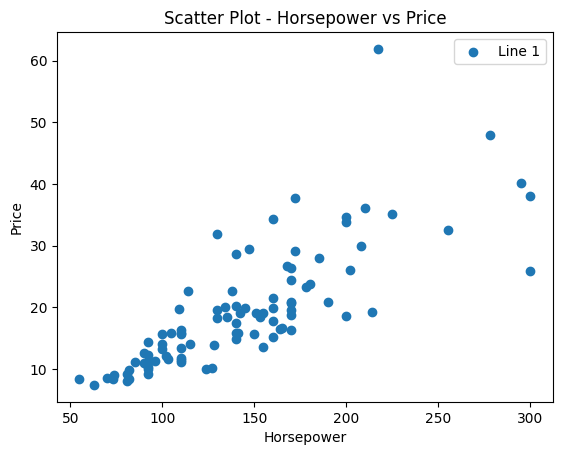

In [ ]:
#SOLUTION_START
paardenkracht = cars["Horsepower"]
prijs = cars["Price"]

plt.figure()
plt.scatter(paardenkracht, prijs, marker='o', label='Line 1') #label wordt enkel gebruikt als je een legende hebt
plt.legend()
plt.title('Scatter Plot - Horsepower vs Price')
plt.xlabel('Horsepower'); plt.ylabel('Price')
plt.savefig('scatter.png', dpi=150, bbox_inches='tight')
#SOLUTION_END


## Vraag 6 — ML-pipeline (train/test + scaling) (10p)

 a) *(4p)*
Stel **X** (kies 2–3 numerieke kolommen, bv. `Horsepower`, `Weight`, `MPG`) en **y** (één target, bv. `FuelType` of `Manufacturer`) op.  
**Split** de data in train en test met `train_size=0.8`.  
Indien `y` een classificatievariabele is, gebruik `stratify=y`.  
*Schrijf in één zin waarom `stratify` nuttig is.*

b) Normaliseer features met `StandardScaler` of `MinMaxScaler`. Toon de vorm van `X_train` vóór en na scaling. *(6p)*


In [19]:
# a
#SOLUTION_START
X = cars[['Horsepower', 'Weight', 'MPG.city']]
y = cars['Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y)
# Opmerking (comment): stratify zorgt ervoor dat de klasseverdeling in train en test ongeveer gelijk blijft, waardoor evaluatie gelijker blijft 
#SOLUTION_END


In [20]:
# b
#SOLUTION_START
pipe = Pipeline([('scaler', StandardScaler())])
X_train_sc = pipe.fit_transform(X_train)
X_test_sc  = pipe.transform(X_test)
print(X_train.shape, X_train_sc.shape)
#SOLUTION_END


(74, 3) (74, 3)


In [ ]:
# b (cursus versie)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Voor scaling:", X_train.shape, "| Na scaling:", X_train_sc.shape)

Voor scaling: (74, 3) | Na scaling: (74, 3)


<function print>

## Vraag 7 — Regressie (Linear & Polynomial) (10p)

 a) *(6p)*
Voer een **LinearRegression** uit met een gekozen numerieke target (bv. `Price`) en enkele numerieke features (bv. `Horsepower`, `Weight`, `MPG.city`).  
Rapporteer **R² (test)**, **MAE**, **RMSE** en toon **coëfficiënten en intercept**

b) *(4p)*
Voeg PolynomialFeatures(graad=2) toe in een Pipeline en vergelijk de R²(test) met (a) in 1–2 zinnen.

In [35]:
# a
#SOLUTION_START

X = cars[['Horsepower', 'Weight', 'MPG.city']]
y = cars['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0, shuffle=True)

model = LinearRegression()

model.fit(X_train, y_train)

print(f'Intercept: {model.intercept_}') 
print(f'Coefficient: {model.coef_}')

#berekeningen doen van de gevraagd values 
y_test_pred = model.predict(X_test)

mae = mean_absolute_error(y_true=y_test, y_pred=y_test_pred)
mse = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
mape = mean_absolute_error(y_true=y_test, y_pred=y_test_pred)
rmse = root_mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred) 

print(f'MAE= {mae:.3f} - MSE = {mse:.3f} - MAPE= {mape:.3f} - RMSE= = {rmse:.3f} - R^2= = {r2:.3f}')
#SOLUTION_END


Intercept: -4.38613522116562
Coefficient: [ 0.11947394  0.00258394 -0.05621725]
MAE= 3.033 - MSE = 17.449 - MAPE= 3.033 - RMSE= = 4.177 - R^2= = 0.760


In [41]:
# b
#SOLUTION_START

poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())

poly_model.fit(X_train, y_train)

y_test_pred = poly_model.predict(X_test)  
mse = mean_squared_error(y_true=y_test, y_pred=y_test_pred)  
r2 = r2_score(y_test, y_test_pred)  
print(f'MSE = {mse:.3f} - R^2= = {r2:.3f}')
#SOLUTION_END


MSE = 20.115 - R^2= = 0.723


## Vraag 8 — Classificatie (Decision Tree / Random Forest) (14p)

 a) DecisionTreeClassifier(max_depth=2) *(6p)*
Toon `get_params()`, accuracy op de test-set en het `classification_report`. Plot een confusion matrix.

 b) *(8p)*
**RandomForestClassifier(n_estimators=200, max_depth=5)**: rapporteer **accuracy** + `classification_report` en plot een **confusion matrix**. Vergelijk kort met de Decision Tree uit (a).

In [ ]:
# a
#SOLUTION_START

#features + target
X = cars[["Horsepower", "Weight", "MPG.city"]]
y = cars["Type"]

#rijen met NaN droppen 
cars_nonan = pd.concat([X, y], axis=1).dropna()
X, y = data[["Horsepower", "Weight", "MPG.city"]], data["Type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,random_state=42 ,stratify=y) # Stratify is used so the classes for the tree are evenly spread as well

model = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_split=5, random_state=42) # Deze opties zijn gewoon een voorbeeld, mogen weg BEHALVE gini
model.fit(X_train, y_train)

# Tonen van het model
print(f"Model classes: {model.classes_}")
plot_tree(model)
#SOLUTION_END

In [ ]:
# b
#SOLUTION_START
# rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
# rf.fit(X_train, y_train)
# y_pred_rf = rf.predict(X_test)
# print('ACC:', (y_pred_rf == y_test).mean())
# print(classification_report(y_test, y_pred_rf))
# # vergelijk in 1-2 zinnen in comment
#SOLUTION_END


## Vraag 9 — Cross-Validation & Hyperparameter Tuning (8p)

a) Voer **5-fold cross-validation** uit (kies model passend bij je task) en print **gemiddelde** en **std** score. *(4p)*  
b) **GridSearchCV** voor `DecisionTreeClassifier` met `{'max_depth':[1,2,3,4,5,6],'criterion':['gini','entropy']}`. Print `best_params_` en `best_score_`. *(4p)*


In [ ]:
# a
#SOLUTION_START
# scores = cross_val_score(tree, X, y, cv=5)
# print(scores.mean(), scores.std())
#SOLUTION_END


In [ ]:
# b
#SOLUTION_START
# grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
#                     param_grid={'max_depth':[1,2,3,4,5,6],'criterion':['gini','entropy']},
#                     cv=5)
# grid.fit(X, y)
# print(grid.best_params_, grid.best_score_)
#SOLUTION_END


## Vraag 10 — K-Means Clustering (8p)

Gebruik 2–3 genormaliseerde numerieke features.  
a) Train **KMeans(n_clusters=3, random_state=42)**; toon `cluster_centers_` en eerste 10 labels. Plot een 2D-scatter met kleur=cluster en markeer centroids. *(5p)*  
b) Leg in 2–3 zinnen uit wat **`n_init`** doet en waarom het nuttig is. *(3p)*


In [ ]:
# a
#SOLUTION_START
# kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
# labels = kmeans.fit_predict(X_train)
# print(kmeans.cluster_centers_)
# print(labels[:10])
# # Plot met plt.scatter(..., c=labels)
#SOLUTION_END


In [ ]:
# b (uitleg in comment)
#SOLUTION_START
# ...
#SOLUTION_END


## Vraag 11 — Neurale Netten (theorie + mini-code) (8p)

a) Leg kort het verschil uit tussen **integratiefunctie** (gewogen som + bias) en **activatiefunctie** (`relu`, `sigmoid`, `softmax`). Wanneer gebruik je **softmax** en welke loss hoort daarbij? *(4p)*  
b) Schrijf pseudocode (of Keras-schets) voor (i) regressie (1 output, `linear` + MSE/MAE) en (ii) classificatie (softmax + categorical crossentropy). *(4p)*


In [ ]:
# a (uitleg in comment)
#SOLUTION_START
# ...
#SOLUTION_END


In [ ]:
# b (pseudocode/keras schets)
#SOLUTION_START
# inputs = ...
# x = Dense(..., activation='relu')(inputs)
# x = Dense(..., activation='relu')(x)
# outputs_reg = Dense(1, activation='linear')(x)          # MSE/MAE
# outputs_cls = Dense(n_classes, activation='softmax')(x)  # categorical_crossentropy
# model_reg = ...
# model_cls = ...
#SOLUTION_END


## Vraag 12 — Meta-heuristiek: Simulated Annealing (8p)

a) Waarom worden soms slechtere oplossingen **toegelaten**? Hoe speelt **temperatuur** hierin mee? *(4p)*  
b) Schrijf pseudo-code: init T, kies buur, Δ, accepteer met kans `exp(-Δ/T)`, verlaag T. Noem 2 afkoelstrategieën. *(4p)*


In [ ]:
# a (uitleg in comment)
#SOLUTION_START
# ...
#SOLUTION_END


In [ ]:
# b (pseudo-code in comment of Python-achtige schets)
#SOLUTION_START
# while T > T_min:
#     neighbor = ...
#     delta = cost(neighbor) - cost(current)
#     if delta < 0: accept
#     else: accept with probability exp(-delta/T)
#     T = alpha * T   # of lineair / logaritmisch afkoelen
#SOLUTION_END


---

### Inlevercheck
- [ ] X/y correct gevormd (X = 2D, y = 1D)
- [ ] Train/test of CV correct; geen datalek tussen train en test
- [ ] Bij classificatie: confusion matrix + ACC/Precision/Recall/F1
- [ ] `.loc`/`.iloc` correct toegepast en slicing-verschil begrepen
- [ ] Cleaning vectorized; NaN’s netjes afgehandeld

**Succes!**